In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from util import seed_everything, get_m, RandomMasking, prepare_qsm_dataset
from util import mask_crop as mask_crop_fn

# ============================================================
# 1. DEVICE & CONFIG
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

EXP_NAME = "msw_to_chh_consistency_hybrid_gpu"
TARGET_VOXELS = 64 * 64 
N_PCA_COMPONENTS = 128
AUG_FACTOR = 5 
NEG_OVERSAMPLE_FACTOR = 10 
seed_everything(0)

UNLABELED_CHH_PATH = "/media/mts_dbs/chh/nii/q" 

qsm_aug = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.5, 1.5)), 
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    RandomMasking(p=0.3)
])

# ============================================================
# 3. EXTRACTION & PCA
# ============================================================
print("\n--- Loading Datasets ---")
dataset_msw = prepare_qsm_dataset('MSW', '/media/mts_dbs/dbs/all/nii/qsm_115/im', 
                                  '/media/mts_dbs/dbs/all/nii/seg_ps/',
                                   '/data/Ali/RadDBS-QSM/data/docs/dbs_03292024.csv', 
                                   'msw_cache_ax.pt', 
                                   load_cache=True, 
                                   mask_crop_fn=mask_crop_fn)

dataset_chh = prepare_qsm_dataset('CHH', '/media/mts_dbs/chh/nii/qsm/',
                                   '/media/mts_dbs/chh/nii/roi/',
                                    '/media/mts_dbs/chh/xlsx/chh_subjects_table1_20240729.csv',
                                    'chh_cache_ax.pt', 
                                    load_cache=True, 
                                    mask_crop_fn=mask_crop_fn, 
                                    unlabeled_nii_path=UNLABELED_CHH_PATH)
def get_mixed_msw_data(dataset, aug_transform=None, factor=1):
    labeled_imgs, labeled_clins, labels = [], [], []
    unlabeled_imgs, unlabeled_clins = [], []
    
    print(f"Processing {len(dataset)} slices...")
    for idx in tqdm(range(len(dataset))):
        img_orig, clin, lbl, _ = dataset[idx]
        
        # CLEAN FIX: Ensure it's 2D [64, 64] regardless of leading dims
        img_np = img_orig.squeeze().numpy() 
        img_flat = img_np.flatten()

        if lbl != -1:
            repeats = NEG_OVERSAMPLE_FACTOR if lbl == 0 else 1
            for _ in range(repeats):
                labeled_imgs.append(img_flat)
                labeled_clins.append(clin.numpy())
                labels.append(lbl)
                
                if aug_transform and factor > 1:
                    for _ in range(factor - 1):
                        # Augment the TENSOR, then flatten
                        aug_tensor = aug_transform(img_orig.clone())
                        labeled_imgs.append(aug_tensor.squeeze().numpy().flatten())
                        labeled_clins.append(clin.numpy())
                        labels.append(lbl)
        else:
            unlabeled_imgs.append(img_flat)
            unlabeled_clins.append(clin.numpy())

    return (np.array(labeled_imgs, dtype=np.float32), 
            np.array(labeled_clins, dtype=np.float32), 
            np.array(labels), 
            np.array(unlabeled_imgs, dtype=np.float32), 
            np.array(unlabeled_clins, dtype=np.float32))

X_train_img, X_train_clin, y_train, X_un_img, X_un_clin = get_mixed_msw_data(dataset_msw, aug_transform=qsm_aug, factor=AUG_FACTOR)

img_scaler = StandardScaler()
X_train_img_scaled = img_scaler.fit_transform(X_train_img)
X_un_img_scaled = img_scaler.transform(X_un_img)

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=0)
pca.fit(np.vstack([X_train_img_scaled, X_un_img_scaled]))

scaler_final = StandardScaler()
X_train_final = scaler_final.fit_transform(np.hstack([pca.transform(X_train_img_scaled), X_train_clin]))

# ============================================================
# TEST SET PREPARATION (FIXED FOR AXIAL ALIGNMENT)
# ============================================================
X_test_img_list, X_test_clin_list, y_test = [], [], []
target_img_shape = X_train_img.shape[1] 

for i in tqdm(range(len(dataset_chh)), desc="Processing Test Slices"):
    img, clin, lbl, _ = dataset_chh[i]
    if lbl != -1:
        img_np = img.numpy().squeeze()
        # FIXED: Changed from [0, :, :] to [:, :, mid] to match Training (Axial)
        if img_np.ndim == 3: 
            img_np = img_np[:, :, img_np.shape[2]//2]
            
        img_flat = img_np.flatten()
        if img_flat.shape[0] != target_img_shape:
            tmp = np.zeros(target_img_shape)
            tmp[:min(img_flat.size, target_img_shape)] = img_flat[:min(img_flat.size, target_img_shape)]
            img_flat = tmp
            
        X_test_img_list.append(img_flat)
        X_test_clin_list.append(clin.numpy())
        y_test.append(lbl)

X_test_img_arr = np.array(X_test_img_list)
X_test_clin_arr = np.array(X_test_clin_list)
y_test = np.array(y_test)

X_test_final = scaler_final.transform(
    np.hstack([pca.transform(img_scaler.transform(X_test_img_arr)), X_test_clin_arr])
)

# ============================================================
# 4. MODEL & GPU TRAINING
# ============================================================
class HybridAE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 64))
        self.decoder = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, input_dim))
        self.classifier_head = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1), nn.Sigmoid())
    def forward(self, x, mode='pretrain'):
        latent = self.encoder(x)
        return self.decoder(latent) if mode == 'pretrain' else self.classifier_head(latent).squeeze()

model = HybridAE(X_train_final.shape[1]).to(device)

# --- Pretraining ---
X_pre_tensor = torch.tensor(X_train_final, dtype=torch.float32).to(device)
pre_loader = DataLoader(TensorDataset(X_pre_tensor), batch_size=128, shuffle=True)
opt_pre, mse = optim.Adam(model.parameters(), lr=1e-3), nn.MSELoss().to(device)
model.train()
for epoch in range(25):
    for b in pre_loader:
        clean = b[0]
        v1, v2 = clean + torch.randn_like(clean)*0.05, clean + torch.randn_like(clean)*0.15
        opt_pre.zero_grad()
        z1, z2 = model.encoder(v1), model.encoder(v2)
        loss = mse(model.decoder(z1), clean) + 0.5 * mse(z1, z2)
        loss.backward(); opt_pre.step()

# --- Fine-Tuning ---
X_ft = torch.tensor(X_train_final, dtype=torch.float32).to(device)
y_ft = torch.tensor(y_train, dtype=torch.float32).to(device)
train_loader = DataLoader(TensorDataset(X_ft, y_ft), batch_size=64, shuffle=True)
opt_ft = optim.Adam(model.parameters(), lr=5e-6, weight_decay=1e-2)
for epoch in range(40):
    for bx, by in train_loader:
        opt_ft.zero_grad()
        loss = nn.functional.binary_cross_entropy(model(bx, mode='fine_tune'), by, weight=(by == 0).float() * 10.0 + 1.0)
        loss.backward(); opt_ft.step()

# ============================================================
# 5. EVALUATION & VISUALIZATION
# ============================================================
clf = LogisticRegression(max_iter=5000, class_weight='balanced', solver='liblinear').fit(X_train_final, y_train)
model.eval()



Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


Using device: cuda

--- Loading Datasets ---
Preparing MSW dataset
Loaded cache with 7790 slices.
Finished MSW: 7790 slices.
Responders: 61 | Nonresponders: 5 | Unlabeled: 45
Preparing CHH dataset
Loaded cache with 2664 slices.
Finished CHH: 2664 slices.
Responders: 34 | Nonresponders: 3 | Unlabeled: 0
Processing 7790 slices...


Processing Test Slices: 100%|██████████| 2664/2664 [00:00<00:00, 32808.12it/s]


HybridAE(
  (encoder): Sequential(
    (0): Linear(in_features=137, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=137, bias=True)
  )
  (classifier_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

In [6]:
with torch.no_grad():
    X_train_clin_only = X_train_final[:, N_PCA_COMPONENTS:]
    X_test_clin_only = X_test_final[:, N_PCA_COMPONENTS:]
    c_clf = LogisticRegression(max_iter=5000, class_weight='balanced', solver='liblinear').fit(X_train_clin_only, y_train)
    y_prob_clin = c_clf.predict_proba(X_test_clin_only)[:, 1]
    y_pred_clin = (y_prob_clin >= 0.5).astype(int)
    y_prob_pca = clf.predict_proba(X_test_final)[:, 1]
    y_pred_pca = (y_prob_pca >= 0.5).astype(int)
    X_test_t = torch.tensor(X_test_final, dtype=torch.float32).to(device)
    y_prob_nn = model(X_test_t, mode='fine_tune').cpu().numpy()
    y_prob_hybrid = (0.6 * y_prob_pca) + (0.4 * y_prob_nn)
    y_pred_hybrid = (y_prob_hybrid >= 0.5).astype(int) 
c_m = get_m(y_test, y_pred_clin, y_prob_clin)
p_m = get_m(y_test, y_pred_pca, y_prob_pca)
h_m = get_m(y_test, y_pred_hybrid, y_prob_hybrid) 
print("\n" + "="*95)
print(f"{'Metric':<15} | {'Clinical LR':<18} | {'Clinical+QSM PCA LR':<18} | {'CONSISTENCY HYBRID':<18}")
print("-" * 95)
for i, name in enumerate(['Accuracy', 'Sensitivity', 'Specificity', 'AUC']):
    print(f"{name:<15} | {c_m[i]:<18.4f} | {p_m[i]:<18.4f} | {h_m[i]:.4f}")
print("-" * 95)
print(f"Conf Hybrid: TP={int(h_m[4])}, TN={int(h_m[5])}, FP={int(h_m[6])}, FN={int(h_m[7])}")
print("="*95)


Metric          | Clinical LR        | Clinical+QSM PCA LR | CONSISTENCY HYBRID
-----------------------------------------------------------------------------------------------
Accuracy        | 0.7027             | 0.7320             | 0.7091
Sensitivity     | 0.7353             | 0.7712             | 0.7230
Specificity     | 0.3333             | 0.2870             | 0.5509
AUC             | 0.6176             | 0.6339             | 0.6773
-----------------------------------------------------------------------------------------------
Conf Hybrid: TP=1770, TN=119, FP=97, FN=678


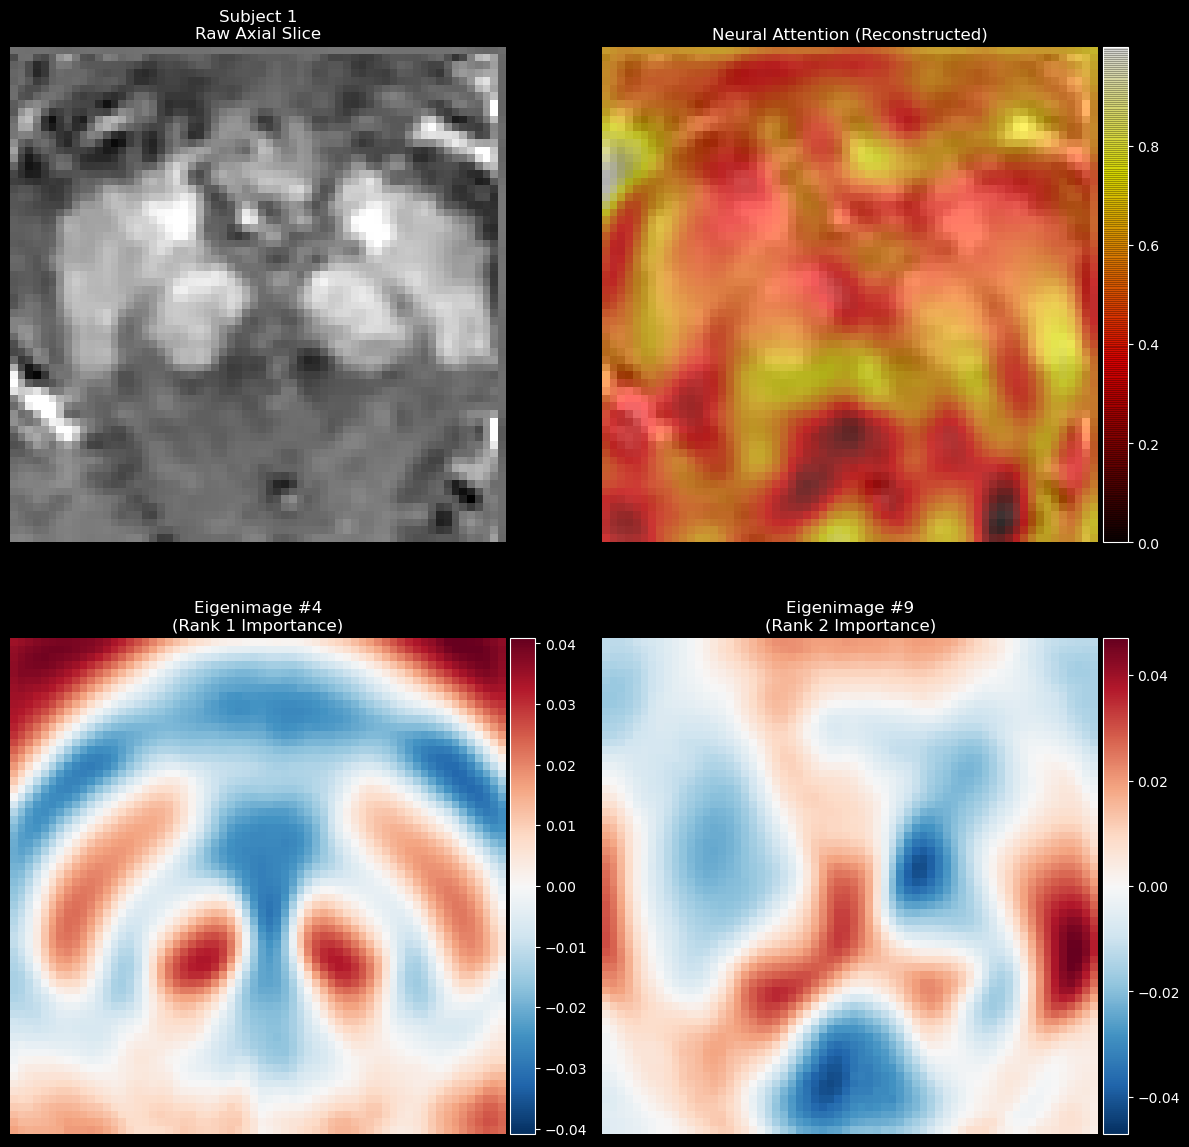

In [7]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def visualize_subject_with_eigen_2x2(subject_idx=0, dataset=dataset_chh):
    model.eval()
    plt.style.use('dark_background')
    
    # 1. DATA EXTRACTION
    all_sub_ids = sorted(list(set(s['sub_id'] for s in dataset.samples)))
    target_sub_id = all_sub_ids[min(subject_idx, len(all_sub_ids)-1)]
    sub_sample_indices = [i for i, s in enumerate(dataset.samples) if s['sub_id'] == target_sub_id]
    mid_sample_idx = sub_sample_indices[len(sub_sample_indices) // 2]
    
    img_tensor, clin_t, lbl, _ = dataset[mid_sample_idx]
    raw_slice = img_tensor.squeeze().numpy() 
    
    # 2. INFERENCE & GRADIENT TRACKING
    flat = raw_slice.flatten().reshape(1, -1)
    scaled = img_scaler.transform(flat)
    pca_feat = pca.transform(scaled)
    final_in = scaler_final.transform(np.hstack([pca_feat, clin_t.numpy().reshape(1, -1)]))
    
    input_t = torch.tensor(final_in, dtype=torch.float32, device=device).requires_grad_()
    out = model(input_t, mode='fine_tune')
    out.backward()
    
    # 3. COMPONENT IMPORTANCE (Top 2)
    grads = input_t.grad.data.abs().cpu().numpy().squeeze()[:128]
    top_2_indices = np.argsort(grads)[-2:][::-1]
    
    # 4. SALIENCY RECONSTRUCTION
    sal_flat = np.dot(grads, pca.components_)
    sal_2d = sal_flat.reshape(64, 64)
    sal_norm = (sal_2d - sal_2d.min()) / (sal_2d.max() - sal_2d.min() + 1e-8)
    
    # 5. 2x2 DISPLAY
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    # helper for colorbars and alignment
    def add_aligned_colorbar(ax, im, visible=True):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        if visible:
            plt.colorbar(im, cax=cax)
        else:
            cax.axis('off')

    # [0, 0] Raw Image (The anchor for size)
    im0 = axes[0, 0].imshow(np.rot90(raw_slice), cmap='gray')
    axes[0, 0].set_title(f"Subject {target_sub_id}\nRaw Axial Slice")
    add_aligned_colorbar(axes[0, 0], im0, visible=False) # Keep size consistent
    
    # [0, 1] Saliency Overlay
    axes[0, 1].imshow(np.rot90(raw_slice), cmap='gray')
    im_sal = axes[0, 1].imshow(np.rot90(sal_norm), cmap='hot', alpha=0.6)
    axes[0, 1].set_title("Neural Attention (Reconstructed)")
    add_aligned_colorbar(axes[0, 1], im_sal)
    
    # [1, 0] & [1, 1] Top 2 Eigenimages
    for i, comp_idx in enumerate(top_2_indices):
        ax_eig = axes[1, i]
        eigen_img = pca.components_[comp_idx].reshape(64, 64)
        v_max = np.abs(eigen_img).max()
        im_eig = ax_eig.imshow(np.rot90(eigen_img), cmap='RdBu_r', vmin=-v_max, vmax=v_max)
        ax_eig.set_title(f"Eigenimage #{comp_idx}\n(Rank {i+1} Importance)")
        add_aligned_colorbar(ax_eig, im_eig)
    
    for ax in axes.flatten():
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Run it
visualize_subject_with_eigen_2x2(subject_idx=0, dataset=dataset_chh)

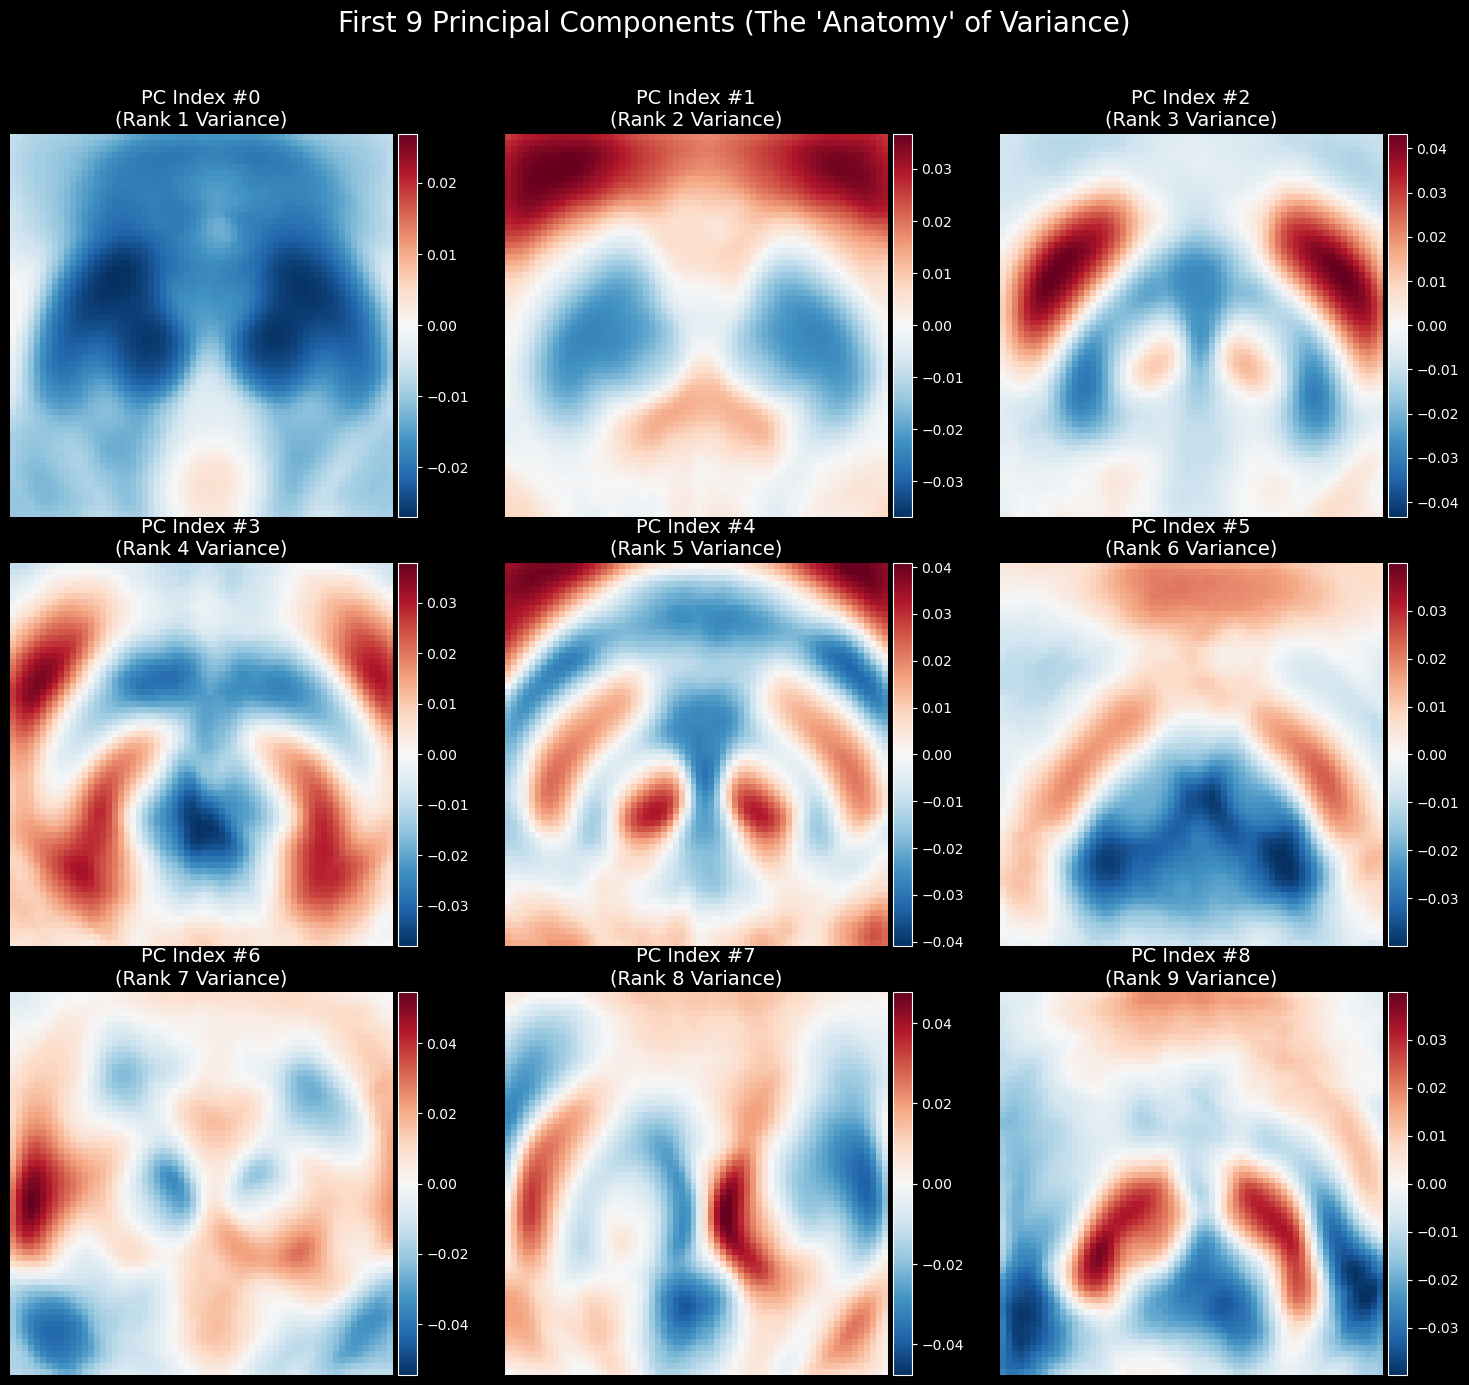

In [8]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_first_9_eigenimages(pca_model):
    """
    Plots the first 9 Principal Components (Eigenimages) in a 3x3 grid.
    These are the components that explain the most variance in the dataset.
    """
    plt.style.use('dark_background')
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    fig.suptitle("First 9 Principal Components (The 'Anatomy' of Variance)", fontsize=20, y=0.95)

    for i in range(9):
        ax = axes[i // 3, i % 3]
        
        # 1. Reshape the i-th component (4096 -> 64x64)
        eigen_img = pca_model.components_[i].reshape(64, 64)
        
        # 2. Symmetric color scale centered at 0
        v_limit = np.abs(eigen_img).max()
        im = ax.imshow(np.rot90(eigen_img), cmap='RdBu_r', vmin=-v_limit, vmax=v_limit)
        
        # 3. Titles & Formatting
        ax.set_title(f"PC Index #{i}\n(Rank {i+1} Variance)", fontsize=14)
        ax.axis('off')
        
        # 4. Aligned Colorbars
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im, cax=cax)

    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()

# Run the visualization
plot_first_9_eigenimages(pca)

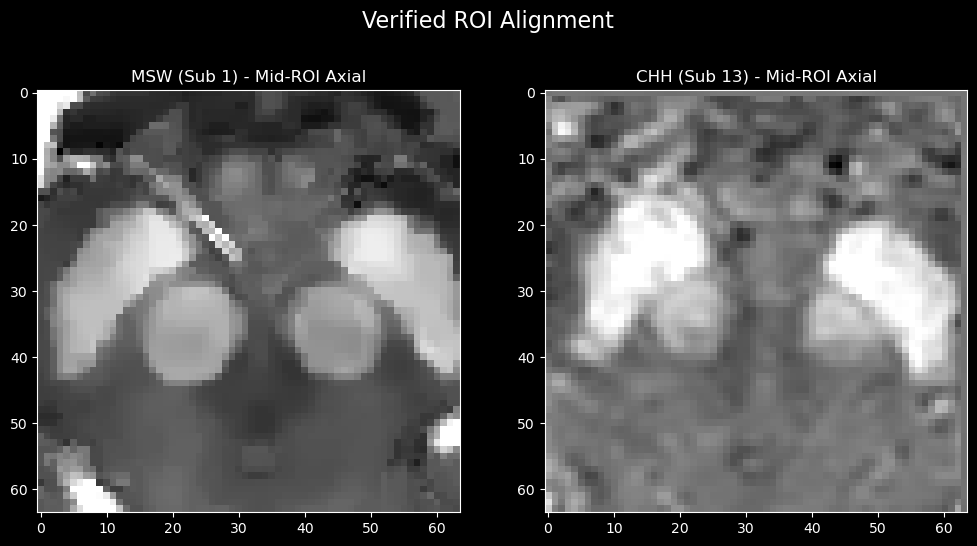

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def verify_dataset_alignment(dataset_train, dataset_test):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    def get_middle_slice_for_subject(dataset):
        # 1. Get the first subject ID in the dataset
        first_sub_id = dataset.samples[0]['sub_id']
        
        # 2. Find all samples belonging to this subject
        sub_samples = [s for s in dataset.samples if s['sub_id'] == first_sub_id]
        
        # 3. Pick the middle index of those samples
        mid_sample_idx = len(sub_samples) // 2
        
        # 4. Get the actual dataset index for that middle sample
        # (This is more robust than just dataset[0])
        actual_idx = dataset.samples.index(sub_samples[mid_sample_idx])
        
        img, _, lbl, _ = dataset[actual_idx]
        return img.numpy().squeeze(), first_sub_id

    # Get slices
    train_slice, train_id = get_middle_slice_for_subject(dataset_train)
    test_slice, test_id = get_middle_slice_for_subject(dataset_test)

    # Display (Using rot90 for human-readable view)
    axes[0].imshow(np.rot90(train_slice), cmap='gray')
    axes[0].set_title(f"MSW (Sub {train_id}) - Mid-ROI Axial")
    
    axes[1].imshow(np.rot90(test_slice), cmap='gray')
    axes[1].set_title(f"CHH (Sub {test_id}) - Mid-ROI Axial")

    plt.suptitle("Verified ROI Alignment", fontsize=16)
    plt.show()

verify_dataset_alignment(dataset_msw, dataset_chh)